In [9]:
from dotenv import load_dotenv
import operator
import json
from typing import Annotated, List, TypedDict
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
# from langgraph.prebuilt import ToolNode, tools_condition

load_dotenv()

True

In [10]:
# 1. State 정의
class GameState(TypedDict):
    year: int
    month: int
    kingdoms: dict
    actions: Annotated[dict, operator.ior]  # 여러 나라의 action을 하나로 묶기 위해서 operator.ior를 사용함
    history: List[str]

In [11]:
# 2. llm 모델 선택
llm = init_chat_model('openai:gpt-4.1-mini', temperature=0.7)

In [ ]:
# 3. 위 / 촉 / 오 공통 노드 양식
def kingdom(state: GameState, kingdom_name: str):

    # 근 6개월 간의 history 검색
        # [디벨롭] history를 임베딩 한 다음에 ChromaDB 등에 담음 >>> 각 나라에서 본인과 타 세력의 관계로그를 검색할 수 있게 함으로서 위의 단점을 해소할 수 있으리라 봄.
    recent_six_month = '\n'.join(state['history'][-6:]) 
    
    # 프롬프트 작성
    # (보완) 다른 세력의 동시간대 action을 넣었어야 하는데, 이를 프롬프트에 넣지 않음
    system_prompt = f'''
    당신은 삼국지 {kingdom_name}나라의 군주입니다.
    목표는 천하통일입니다. 현재 상황을 보고 이번 달에 취할 하나의 행동을 결정하세요.
    행동의 종류는 다음과 같습니다 : 전투(도시 함락) / 외교(친선, 동맹 등) / 계략(내통자 포섭 등) / 내정

    현재 상황: {state['kingdoms'][kingdom_name]}
    과거 역사: {recent_six_month}

    **어떠한 부연 설명도 하지 말고, 반드시 아래의 JSON 형식으로만 답변을 출력하세요.**
    {{
        "행동_종류": "[전투, 외교, 계략, 내정 중 가장 적절한 것 1개 선택]",
        "상세_행동": "[현재 상황을 반영하여 군주로서 내리는 구체적인 지시를 1문장으로 작성]"
    }}
    
    '''
    
    # llm 모델을 통해 actions를 생성하기
    response = llm.invoke([{'role': 'system', 'content': system_prompt}, 
                           {'role': 'user', 'content': '이번 달 우리의 전략은 무엇입니까?'}])
    
    result_data = json.loads(response.content)
    action_text = result_data.get("상세_행동", "")

    # 사용자가 해당 세력이 어떠한 행동을 했는지 확인할 수 있도록 print 구문 출력
    print(f'{kingdom_name}나라의 행동 : {action_text}')
    
    # 해당 나라의 행동을 state에 저장
    return {'actions': {kingdom_name: action_text}}

In [ ]:
# 4. 세 세력 행동 후 결과를 결정할 심판 노드
def judge(state: GameState):
    
    # (1) action과 kingdom state 결정
    actions = state['actions']
    kingdoms = state['kingdoms']
    
    system_prompt = f'''
    당신은 삼국지의 심판입니다. 아래 세 나라의 행동을 판정하세요.
    
    [현재 세력 상태]
    {json.dumps(kingdoms, ensure_ascii=False)}
    
    [각 나라의 행동]
    {json.dumps(actions, ensure_ascii=False)}
    
    **결과는 반드시 아래 JSON 형식으로만 답변하세요:**
    {{
        "description": "세 세력이 행동한 결과에 대한 상세한 역사적 묘사 (한 문장)",
        "updated_kingdoms":{{ 
            "위": {{ 보유_도시 등 수정된 위나라 전체 데이터 }},
            "촉": {{ 보유_도시 등 수정된 촉나라 전체 데이터 }},
            "오": {{ 보유_도시 등 수정된 오나라 전체 데이터 }}
    }}
    }}

    **주의: 한 세력이 획득한 도시는 다른 세력으로부터 탈취한 도시여야 합니다.**
    '''
    # [디벨롭] llm에 의존하지 않고, all_star_lineup.jsonl에 있는 데이터를 기반으로 전투 승패를 가르는 tool을 만들었다면 더 좋았을 듯.

    # 여기서 LLM이 판정 결과를 생성
    response = llm.invoke(system_prompt)
    
    result_data = json.loads(response.content)
    result_text = result_data['description']
    updated_kingdoms = result_data['updated_kingdoms']

     # 결과 문장을 history에 추가
    new_history = state['history'] + [f"[{state['year']}년 {state['month']}개월] {result_text}"]
    # 사용자도 볼 수 있게 출력
    print(f'[{state['year']}년 {state['month']}개월] {result_text}')

    # 시스템 업데이트
    new_month = state['month'] + 1
    new_year = state['year']
    if new_month > 12:
        new_month = 1
        new_year += 1
    
    return {
        'year': new_year,
        'month': new_month,
        'kingdoms' : updated_kingdoms,
        'history': new_history,
        'actions': {}, # 다음 턴을 위해 행동 초기화
    }

In [ ]:
# 0년부터 시작해 n년이 되면 종료되도록 함수 정의

def check_limit(state: GameState):
    if state['year'] >= 1:
        return END
    else:
        return '위'

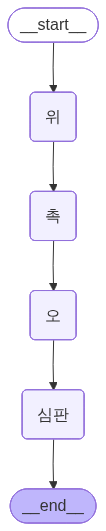

In [15]:
builder = StateGraph(GameState)
# tool_node = ToolNode(tools)

builder.add_node('위', lambda x: kingdom(x, '위'))
builder.add_node('촉', lambda x: kingdom(x, '촉'))
builder.add_node('오', lambda x: kingdom(x, '오'))
builder.add_node("심판", judge)

# 사실상 오나라는 위와 촉나라 행동을 보고 움직이기 때문에 오나라에게 매우 유리한 규칙
builder.add_edge(START, '위')   # 맨 처음
builder.add_edge('위', '촉')    # 위 -> 촉
builder.add_edge('촉', '오')
builder.add_edge('오', '심판')
builder.add_conditional_edges('심판', check_limit)

graph = builder.compile()
graph


In [16]:
with open('../data/three_kingdoms_status.json', 'r', encoding='utf-8') as f:
    kingdoms_default = json.load(f)

initial_state = {
    "year": 0,
    "month": 1,
    "kingdoms": kingdoms_default,
    "actions": {},
    "history": []
}

# 실행
final_state = graph.invoke(initial_state)

위나라의 행동 : 내실을 더욱 다지기 위해 농업과 군수 산업을 발전시키고, 도시 방어 체계를 강화하라.
촉나라의 행동 : 금과 곡식이 부족하므로 농업 생산과 자원 관리에 집중하여 경제 기반을 강화하고 북벌 준비를 위한 병참 보급을 확충하라.
오나라의 행동 : 풍부한 병력과 자원을 바탕으로 주변 적의 약한 요충지를 공략하여 영토 확장에 나아가라.
[0년 1개월] 위나라는 농업과 군수 산업을 발전시키고 방어 체계를 강화하여 안정적인 내실을 더욱 공고히 하였고, 촉은 경제 기반 강화를 위해 농업과 자원 관리를 집중하여 북벌 준비에 필요한 병참 보급을 확충하였으며, 오는 풍부한 자원과 병력을 바탕으로 주변 약한 요충지를 성공적으로 공략하여 영토를 확장하였다.
위나라의 행동 : 사마의와 순욱을 중심으로 촉의 내부 분열을 유도하고, 내통자를 포섭하여 촉의 북벌 준비를 방해하라.
촉나라의 행동 : 북벌 준비를 위해 성도와 한중 지역의 농업 생산력을 더욱 강화하고 병참 보급 체계를 최적화하라.
오나라의 행동 : 풍족한 자원과 병력을 바탕으로 주요 약한 요충지 방어를 강화하고 무역 활성화를 더욱 촉진하여 안정적인 경제 기반을 다진다.
[0년 2개월] 위나라는 사마의와 순욱의 간계로 촉 내부에 긴장과 분열을 조성하며 북벌 준비를 저해하는 데 성공했고, 촉은 농업과 병참 보급을 강화하여 북벌 기반을 다졌으나 내부 혼란의 영향으로 완전한 효율을 내지 못했으며, 오는 요충지 방어를 튼튼히 하면서 무역 활성화로 경제적 안정과 군사력 증강을 동시에 이뤄냈다.
위나라의 행동 : 풍부한 병력과 자원을 바탕으로 촉의 내부 분열을 이용해 약화된 촉의 요충지를 신속히 공격하여 영토를 확장한다.
촉나라의 행동 : 내부 긴장을 해소하고 북벌 준비를 원활히 하기 위해 사마의와 순욱의 내통자를 포섭하여 적의 분열 전략을 무력화하라.
오나라의 행동 : 풍부한 병력과 안정된 경제를 바탕으로 주변 약한 요충지를 집중 공략하여 영토 확장을 가속화하라.
[0년 3개월] 위나라는 촉의 내부 분열을 효과적으로 이용

KeyboardInterrupt: 

### Streamlit 구현 전략
- 매달 위,촉,오의 행동과 이에 대한 결과값 출력 (이전 기록은 지우면서)
- 과거 로그는 특정 버튼을 누르면 창이 떠서 스크롤해서 볼 수 있도록